## 1 Imports

In [15]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2 Paths and Parameters (List of Gamma values)

In [16]:
input_path = Path(r"D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\highlights_and_shadows.jpg")
output_dir = Path(r"D:\MSc in AI\1YQ3\CV\Assignment_1\results\q02")
output_dir.mkdir(parents=True, exist_ok=True)

gamma_values = [0.5, 0.8, 1.2]
final_gamma = 0.8

## 3 Helper Functions

In [17]:
def gamma_transform(image_norm: np.ndarray, gamma: float) -> np.ndarray:
    """Apply gamma correction to a normalized image in [0, 1]."""
    return np.power(image_norm, gamma)


def to_uint8(image_norm: np.ndarray) -> np.ndarray:
    """Convert normalized image in [0, 1] to uint8 in [0, 255]."""
    return np.clip(image_norm * 255, 0, 255).astype(np.uint8)

## 4 Load Image

In [18]:
img_bgr = cv2.imread(str(input_path), cv2.IMREAD_COLOR)

if img_bgr is None:
    raise FileNotFoundError(f"Could not load image: {input_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Shape:", img_rgb.shape)
print("dtype:", img_rgb.dtype)

Shape: (480, 720, 3)
dtype: uint8


## 5 Convert to LAB and extract channels

In [19]:
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L_original, a, b = cv2.split(img_lab)

L_norm = L_original.astype(np.float32) / 255.0

print("L channel shape:", L_original.shape)
print("L min:", L_original.min(), "L max:", L_original.max())

L channel shape: (480, 720)
L min: 0 L max: 255


## 6 All gamma results in a loop

In [20]:
results = []

for gamma in gamma_values:
    L_corrected_norm = gamma_transform(L_norm, gamma)
    L_corrected = to_uint8(L_corrected_norm)

    img_lab_corrected = cv2.merge((L_corrected, a, b))
    img_bgr_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
    img_rgb_corrected = cv2.cvtColor(img_bgr_corrected, cv2.COLOR_BGR2RGB)

    results.append({
        "gamma": gamma,
        "L_corrected": L_corrected,
        "img_bgr_corrected": img_bgr_corrected,
        "img_rgb_corrected": img_rgb_corrected,
        "mean_L": L_corrected.mean(),
        "std_L": L_corrected.std()
    })

## 7 Original plus all gamma-corrected images.

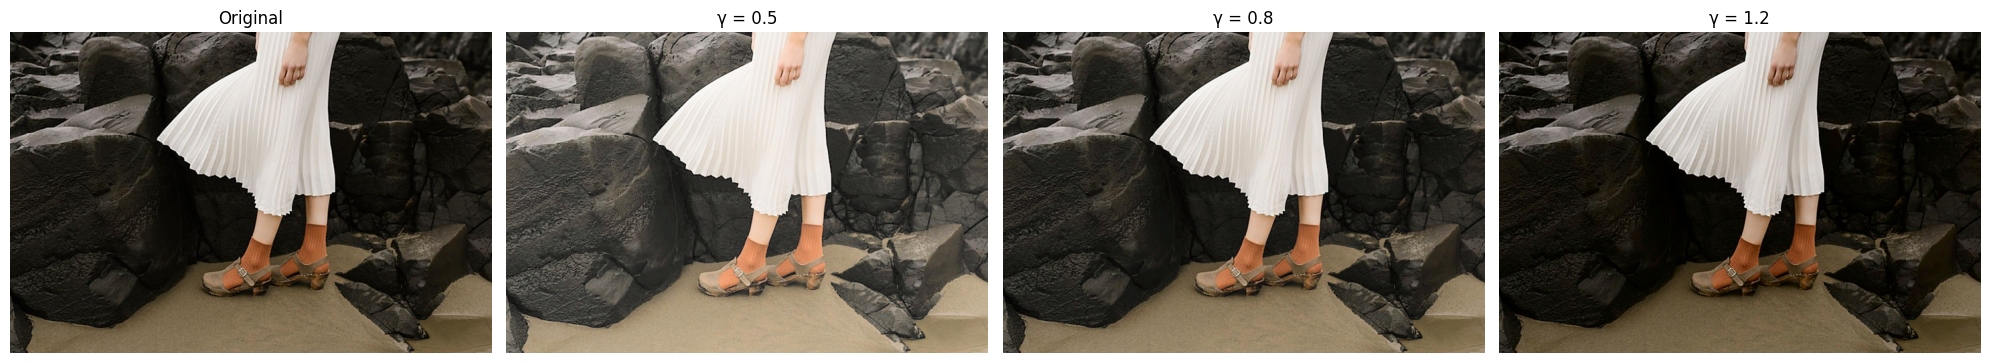

In [21]:
fig, axes = plt.subplots(1, len(results) + 1, figsize=(5 * (len(results) + 1), 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

for i, result in enumerate(results, start=1):
    axes[i].imshow(result["img_rgb_corrected"])
    axes[i].set_title(f"γ = {result['gamma']}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 8 Histogram comparison for all tested gammas

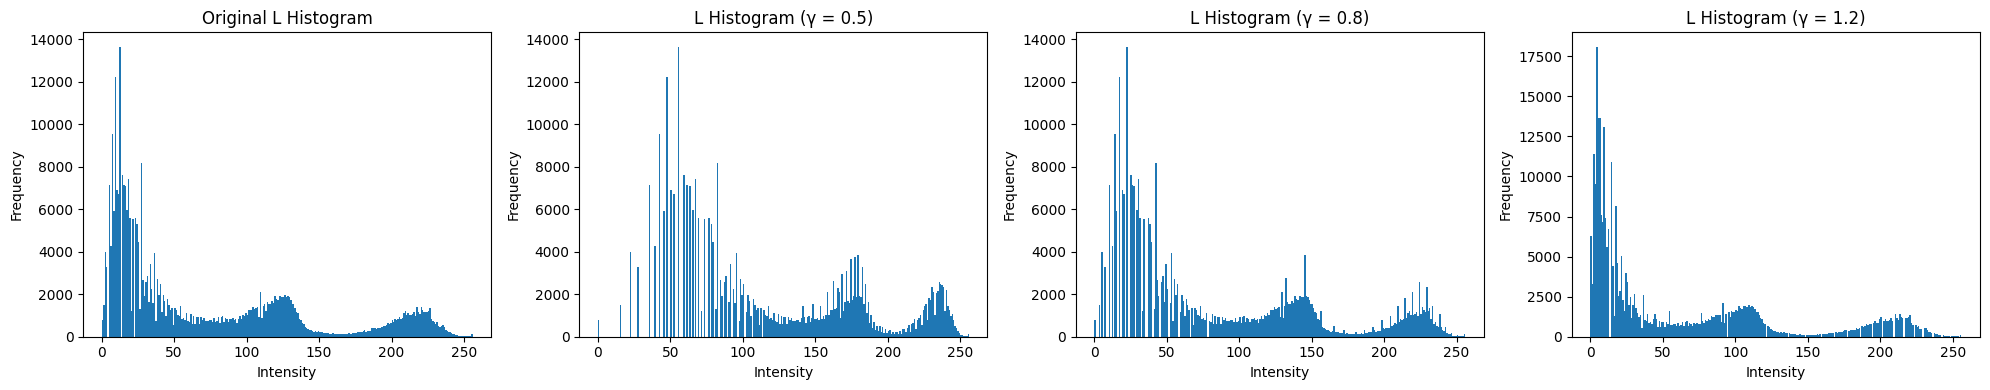

In [22]:
fig, axes = plt.subplots(1, len(results) + 1, figsize=(5 * (len(results) + 1), 4))

axes[0].hist(L_original.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original L Histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Frequency")

for i, result in enumerate(results, start=1):
    axes[i].hist(result["L_corrected"].ravel(), bins=256, range=(0, 256))
    axes[i].set_title(f"L Histogram (γ = {result['gamma']})")
    axes[i].set_xlabel("Intensity")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 9 Select final gamma result for reporting

In [23]:
final_result = next(r for r in results if r["gamma"] == final_gamma)

L_corrected = final_result["L_corrected"]
img_bgr_corrected = final_result["img_bgr_corrected"]
img_rgb_corrected = final_result["img_rgb_corrected"]

## 10 Final report figure using the selected gamma only

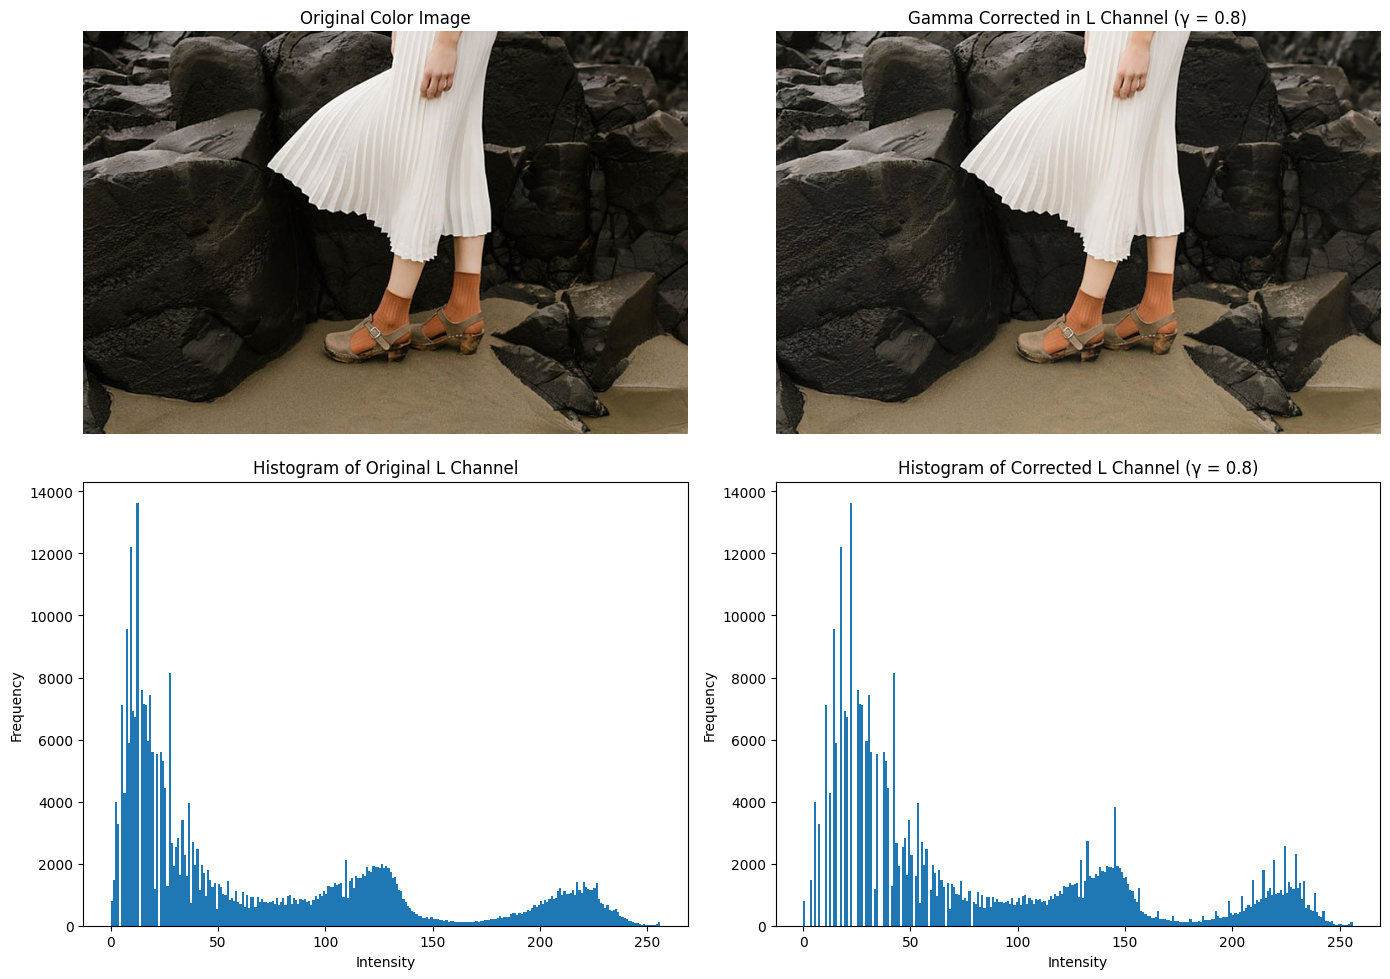

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Color Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected in L Channel (γ = {final_gamma})")
axes[0, 1].axis("off")

axes[1, 0].hist(L_original.ravel(), bins=256, range=(0, 256))
axes[1, 0].set_title("Histogram of Original L Channel")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(L_corrected.ravel(), bins=256, range=(0, 256))
axes[1, 1].set_title(f"Histogram of Corrected L Channel (γ = {final_gamma})")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(output_dir / "q02_results.png", dpi=300, bbox_inches="tight")
plt.show()

## 11 Save all tested outputs, plus the final selected result

In [25]:
cv2.imwrite(str(output_dir / "original_bgr.png"), img_bgr)
cv2.imwrite(str(output_dir / "original_L.png"), L_original)

for result in results:
    gamma_str = str(result["gamma"]).replace(".", "_")
    cv2.imwrite(str(output_dir / f"corrected_gamma_{gamma_str}.png"), result["img_bgr_corrected"])
    cv2.imwrite(str(output_dir / f"L_gamma_{gamma_str}.png"), result["L_corrected"])

cv2.imwrite(str(output_dir / "corrected_bgr_final.png"), img_bgr_corrected)
cv2.imwrite(str(output_dir / "corrected_L_final.png"), L_corrected)

print("Q2 - LAB Gamma Correction")
print(f"Tested gamma values: {gamma_values}")
print(f"Selected gamma value for final report: {final_gamma}")
print(f"Results saved to: {output_dir}")

Q2 - LAB Gamma Correction
Tested gamma values: [0.5, 0.8, 1.2]
Selected gamma value for final report: 0.8
Results saved to: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q02


## 12 Print comparison statistics for all gamma values.

In [26]:
print(f"{'Gamma':<10}{'Mean L':<15}{'Std L':<15}")
print("-" * 40)
print(f"{'Original':<10}{L_original.mean():<15.2f}{L_original.std():<15.2f}")

for result in results:
    print(f"{result['gamma']:<10}{result['mean_L']:<15.2f}{result['std_L']:<15.2f}")

Gamma     Mean L         Std L          
----------------------------------------
Original  71.26          69.73          
0.5       117.30         65.43          
0.8       84.55          70.08          
1.2       60.69          68.24          
